# Finetuning Training-State Plots

Reusable utilities to load a Hugging Face Trainer state JSON and plot finetuning metrics for one or multiple runs.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')

In [2]:
def load_trainer_log(json_path):
    """Load trainer_state.json and return (trainer_state, dataframe)."""
    path = Path(json_path)
    if not path.exists():
        raise FileNotFoundError(f'JSON file not found: {path}')

    with path.open('r', encoding='utf-8') as f:
        trainer_state = json.load(f)

    log_history = trainer_state.get('log_history', [])
    if not log_history:
        raise ValueError(f'No log_history found in JSON: {path}')

    df = pd.DataFrame(log_history)
    if 'step' in df.columns:
        df = df.sort_values('step')
    df = df.reset_index(drop=True)

    for col in ['step', 'epoch', 'loss', 'learning_rate', 'grad_norm']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    return trainer_state, df


def plot_finetuning_log(json_path, metrics=None, show_epoch_plots=True, show_summary=True):
    """Plot metrics from a trainer_state JSON path."""
    trainer_state, df = load_trainer_log(json_path)

    if metrics is None:
        metrics = ['loss', 'learning_rate', 'grad_norm']
    metrics = [m for m in metrics if m in df.columns]

    if not metrics:
        raise ValueError('None of the requested metrics are present in log_history.')

    print(f'Loaded: {json_path}')
    print(f"Global step: {trainer_state.get('global_step')} / Max steps: {trainer_state.get('max_steps')}")
    print(f"Epoch: {trainer_state.get('epoch')}")
    print(f'Rows in log_history: {len(df)}')

    display(df.head())
    display(df.tail())

    # Plot by step
    n = len(metrics)
    fig, axes = plt.subplots(n, 1, figsize=(12, 4 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        sns.lineplot(data=df, x='step', y=metric, ax=ax, linewidth=1.5)
        ax.set_title(f'{metric} over training steps')
        ax.set_xlabel('step')
        ax.set_ylabel(metric)

    plt.tight_layout()
    plt.show()

    # Plot by epoch
    if show_epoch_plots and 'epoch' in df.columns:
        fig, axes = plt.subplots(n, 1, figsize=(12, 4 * n), sharex=True)
        if n == 1:
            axes = [axes]

        for ax, metric in zip(axes, metrics):
            sns.lineplot(data=df, x='epoch', y=metric, ax=ax, linewidth=1.5)
            ax.set_title(f'{metric} over epochs')
            ax.set_xlabel('epoch')
            ax.set_ylabel(metric)

        plt.tight_layout()
        plt.show()

    if show_summary:
        summary = df[metrics].describe(percentiles=[0.1, 0.5, 0.9]).T
        display(summary)

    return trainer_state, df

Loaded: /home/franchini/Master-Thesis/matryoshka_optimization_codebase/outputs/models/nomic_mrl_msmarco/checkpoints/checkpoint-792622/trainer_state.json
Global step: 792622 / Max steps: 792622
Epoch: 1.0
Rows in log_history: 15852


,epoch,grad_norm,learning_rate,loss,step
0,0.000063,39.731930,1.160693e-08,1.6118,50
1,0.000126,26.504160,2.397083e-08,1.6942,100
2,0.000189,34.748032,3.658706e-08,1.6284,150
3,0.000252,33.050766,4.920329e-08,1.7123,200
4,0.000315,86.618950,6.181951e-08,1.4969,250


,epoch,grad_norm,learning_rate,loss,step
15847,0.999720,0.584752,1.480321e-08,0.0425,792400
15848,0.999783,0.197799,1.340139e-08,0.0238,792450
15849,0.999846,0.388605,1.199957e-08,0.0183,792500
15850,0.999909,0.523124,1.059775e-08,0.0438,792550
15851,0.999972,0.053722,9.195931e-09,0.0231,792600


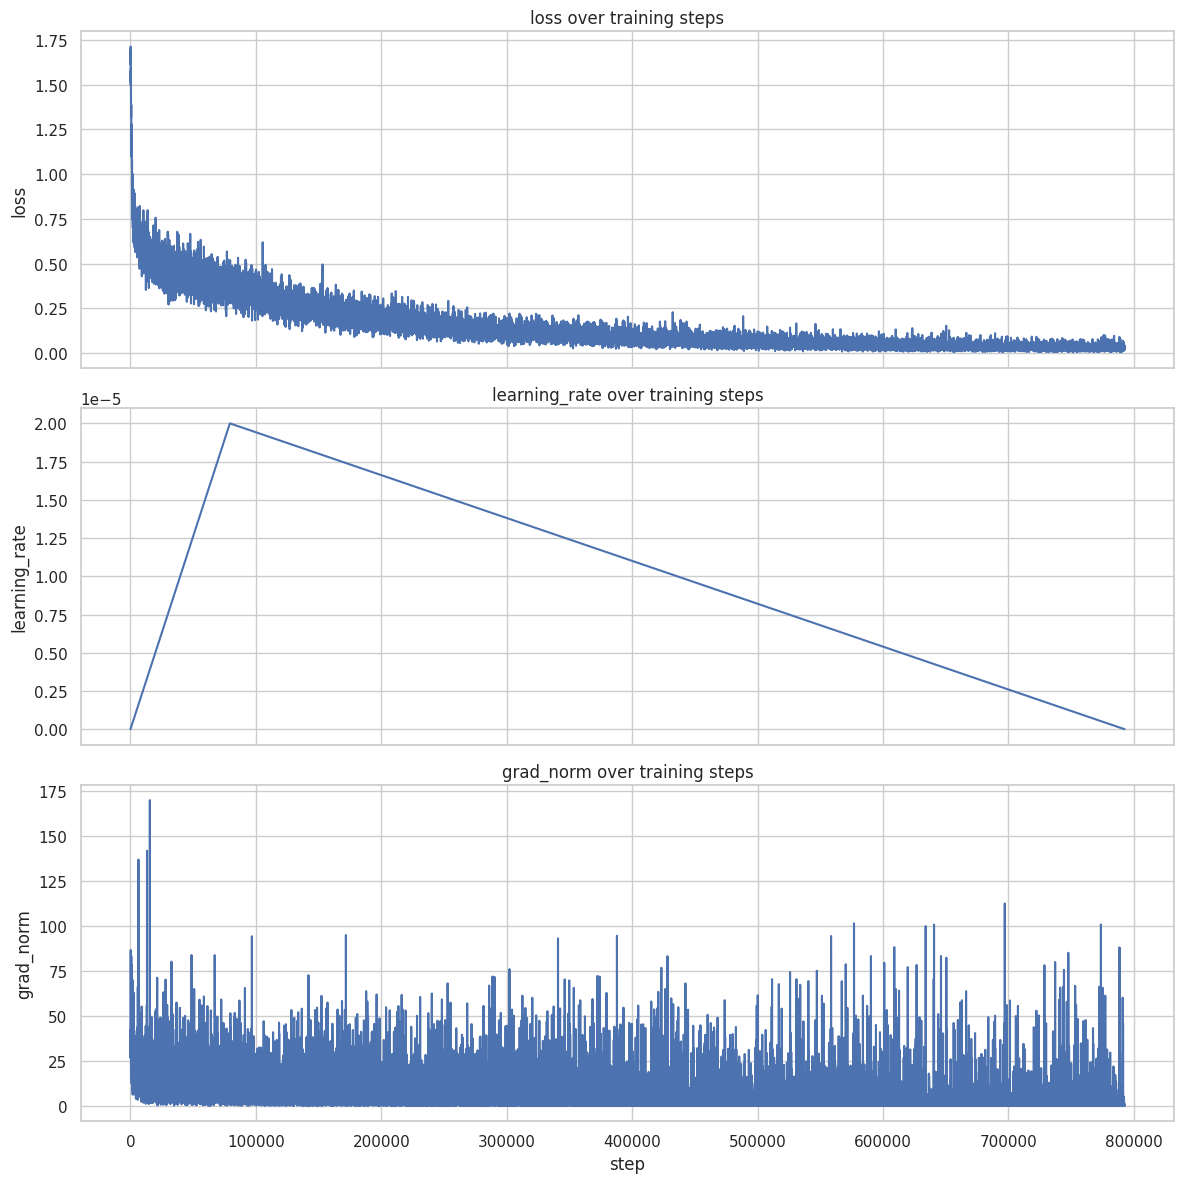

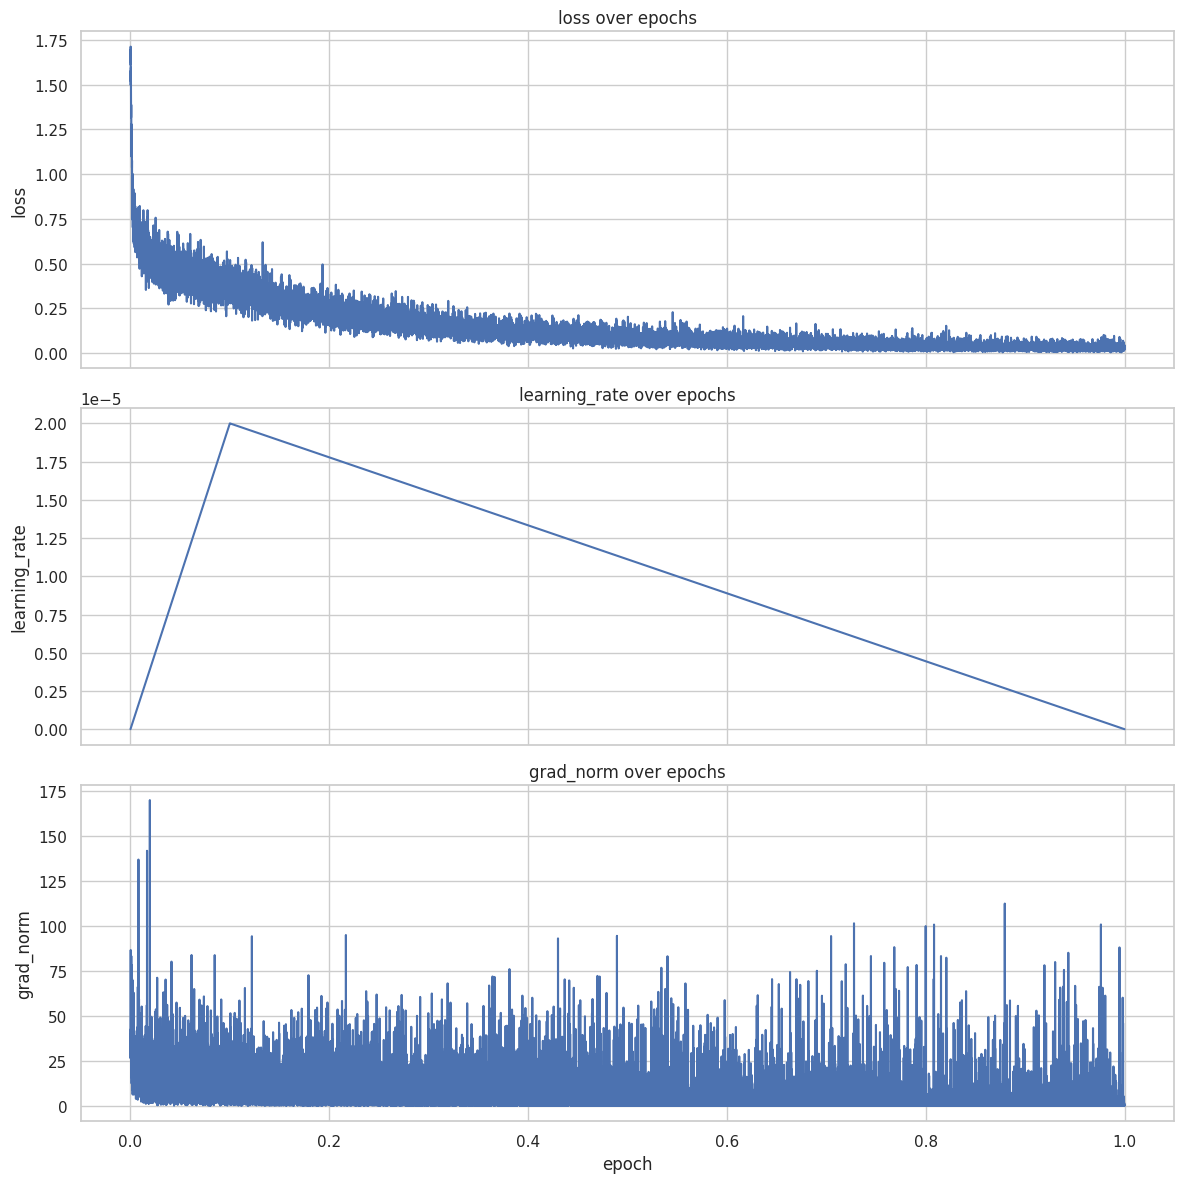

/home/franchini/Master-Thesis/.venv/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,10%,50%,90%,max
loss,15852.0,0.142944,0.150474,2.900000e-03,0.025400,0.084300,0.360490,1.71230
learning_rate,15852.0,0.000010,0.000006,9.195931e-09,0.000002,0.000010,0.000018,0.00002
grad_norm,15852.0,inf,NaN,4.934874e-03,0.075923,1.540662,21.943490,inf


In [3]:
# Example usage: duplicate this cell for each model
trainer_state, df = plot_finetuning_log("/home/franchini/Master-Thesis/matryoshka_optimization_codebase/outputs/models/nomic_mrl_msmarco/checkpoints/checkpoint-792622/trainer_state.json")